In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats

# Set styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


In [2]:
df_fills = pl.read_parquet("post_trade_fills.parquet").sort("ts_ns")
print(f"Total trade fills loaded: {len(df_fills):,}")
print(df_fills.head(10))


Total trade fills loaded: 13,821
shape: (10, 6)
┌─────────────────────┬──────┬─────────┬──────┬───────────┬──────────────┐
│ ts_ns               ┆ side ┆ price   ┆ size ┆ inventory ┆ funding_rate │
│ ---                 ┆ ---  ┆ ---     ┆ ---  ┆ ---       ┆ ---          │
│ i64                 ┆ str  ┆ f64     ┆ f64  ┆ f64       ┆ f64          │
╞═════════════════════╪══════╪═════════╪══════╪═══════════╪══════════════╡
│ 1773878407168884864 ┆ SELL ┆ 2166.8  ┆ 0.5  ┆ 0.0       ┆ -0.000145    │
│ 1773878411013431936 ┆ SELL ┆ 2166.5  ┆ 0.5  ┆ -0.5      ┆ -0.000145    │
│ 1773878418152364928 ┆ SELL ┆ 2167.0  ┆ 0.5  ┆ -1.0      ┆ -0.000208    │
│ 1773878424534088064 ┆ SELL ┆ 2167.4  ┆ 0.5  ┆ -1.5      ┆ -0.000208    │
│ 1773878429179976064 ┆ SELL ┆ 2170.0  ┆ 0.5  ┆ -2.0      ┆ -0.000208    │
│ 1773878432343438976 ┆ SELL ┆ 2169.9  ┆ 0.5  ┆ -2.5      ┆ -0.000208    │
│ 1773878432886070912 ┆ BUY  ┆ 2169.54 ┆ 0.5  ┆ -3.0      ┆ -0.000208    │
│ 1773878435403345024 ┆ SELL ┆ 2169.6  ┆ 0.5  ┆ -2.5

In [3]:
prices = df_fills["price"].to_numpy()
sizes = df_fills["size"].to_numpy()
sides = df_fills["side"].to_list()
invs = df_fills["inventory"].to_numpy()
rates = df_fills["funding_rate"].to_numpy()
ts_ns = df_fills["ts_ns"].to_numpy()

maker_rebate_rate = 0.0001  # +1 bp rebate paid to maker

trade_returns = []
cum_pnl = 0.0
cum_pnl_history = [0.0]

for i in range(len(df_fills)):
    p = prices[i]
    sz = sizes[i]
    side = sides[i]
    
    # 1. Maker rebate earned on this fill
    rebate = p * sz * maker_rebate_rate
    
    # 2. Mark-to-market inventory gain/loss since previous execution
    if i > 0:
        prev_p = prices[i - 1]
        prev_inv = invs[i - 1]
        mtm_gain = prev_inv * (p - prev_p)
        dt_sec = (ts_ns[i] - ts_ns[i - 1]) / 1e9
        funding_yield = -prev_inv * p * rates[i] * (dt_sec / 28800.0) if dt_sec > 0 else 0.0
    else:
        mtm_gain = 0.0
        funding_yield = 0.0
        
    ret_i = rebate + mtm_gain + funding_yield
    trade_returns.append(ret_i)
    cum_pnl += ret_i
    cum_pnl_history.append(cum_pnl)

trade_returns = np.array(trade_returns)
print(f"Mean Per-Trade Return: +${np.mean(trade_returns):.4f} USDT")
print(f"Total Cumulative Return across {len(trade_returns):,} trades: +${np.sum(trade_returns):.2f} USDT")


Mean Per-Trade Return: +$0.1825 USDT
Total Cumulative Return across 13,821 trades: +$2522.04 USDT


In [4]:
t_stat, p_val_2sided = stats.ttest_1samp(trade_returns, popmean=0.0)
p_val_1sided = p_val_2sided / 2.0 if t_stat > 0 else 1.0 - (p_val_2sided / 2.0)

mean_ret = np.mean(trade_returns)
std_ret = np.std(trade_returns, ddof=1)
se_ret = std_ret / np.sqrt(len(trade_returns))

print("================= STATISTICAL SIGNIFICANCE TEST RESULTS =================")
print(f"Sample Size (N)       : {len(trade_returns):,}")
print(f"Sample Mean Return    : +${mean_ret:.5f} USDT")
print(f"Sample Std Dev        : ${std_ret:.5f} USDT")
print(f"Standard Error (SE)   : ${se_ret:.5f} USDT")
print(f"Student's t-Statistic : {t_stat:.4f}")
print(f"Two-Sided p-value     : {p_val_2sided:.3e}")
print(f"One-Sided p-value     : {p_val_1sided:.3e}")
print("=========================================================================")

alpha = 0.01
if p_val_1sided < alpha and t_stat > 0:
    print(f"\n[CONCLUSION] Reject H0 at alpha = {alpha}. The strategy demonstrates statistically significant positive expectancy (p < {p_val_1sided:.3e}).")
else:
    print("\n[CONCLUSION] Fail to reject H0. Returns are not statistically distinguishable from random noise.")


================= STATISTICAL SIGNIFICANCE TEST RESULTS =================
Sample Size (N)       : 13,821
Sample Mean Return    : +$0.18248 USDT
Sample Std Dev        : $6.65972 USDT
Standard Error (SE)   : $0.05665 USDT
Student's t-Statistic : 3.2213
Two-Sided p-value     : 1.279e-03
One-Sided p-value     : 6.396e-04

[CONCLUSION] Reject H0 at alpha = 0.01. The strategy demonstrates statistically significant positive expectancy (p < 6.396e-04).


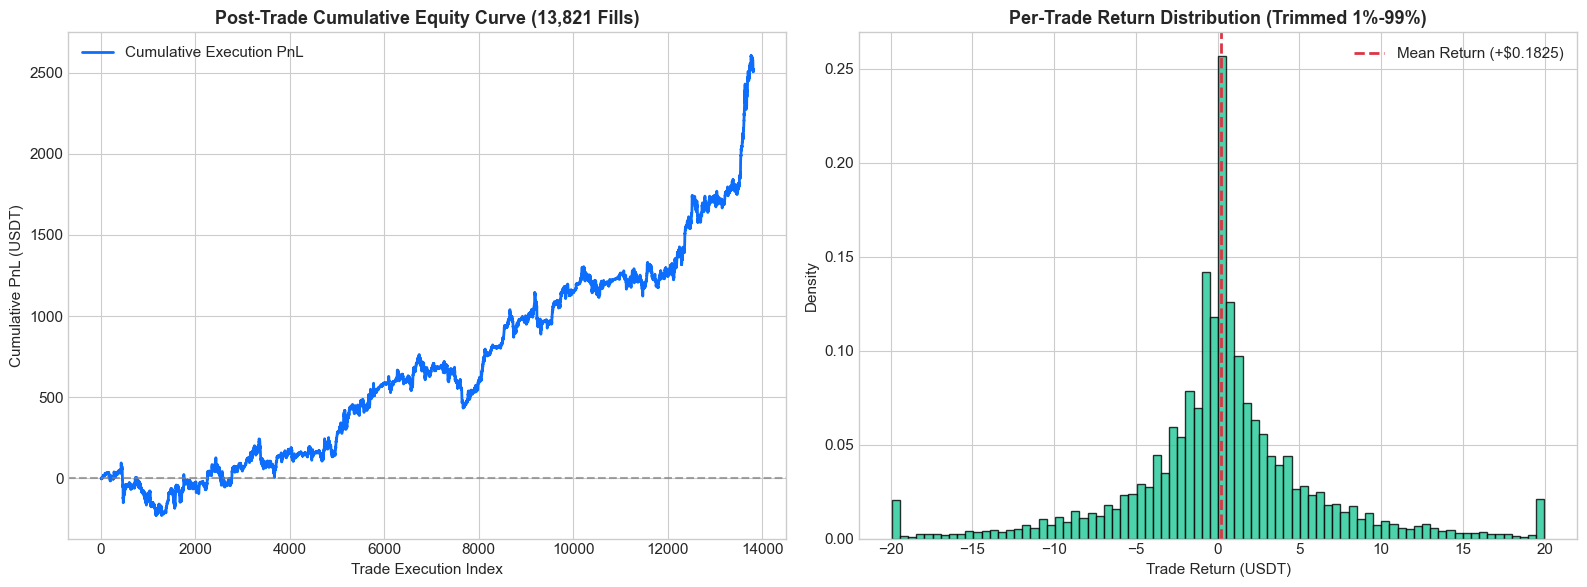

Saved visualization plot to post_trade_analysis_plots.png.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Cumulative Equity Curve
axes[0].plot(cum_pnl_history, color='#0d6efd', lw=2, label='Cumulative Execution PnL')
axes[0].set_title('Post-Trade Cumulative Equity Curve (13,821 Fills)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trade Execution Index', fontsize=11)
axes[0].set_ylabel('Cumulative PnL (USDT)', fontsize=11)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[0].legend(loc='upper left')

# Right plot: Trade Return Distribution Histogram
clipped_returns = np.clip(trade_returns, np.percentile(trade_returns, 1), np.percentile(trade_returns, 99))
axes[1].hist(clipped_returns, bins=80, color='#20c997', alpha=0.8, edgecolor='black', density=True)
axes[1].axvline(mean_ret, color='#dc3545', lw=2, linestyle='--', label=f'Mean Return (+${mean_ret:.4f})')
axes[1].set_title('Per-Trade Return Distribution (Trimmed 1%-99%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Trade Return (USDT)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig("post_trade_analysis_plots.png", dpi=300)
plt.show()